### [식용 & 독버섯 분류 - DecisionTree] <hr>

In [1]:
## 데이터 관련
import pandas as pd
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt, koreanize_matplotlib
import seaborn as sns

## ML 교차검증 관련
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

## ML 전처리 관련
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

## ML 모델 관련
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib, os
MODEL_FILE = '../Models/mushroom_model.pkl'

In [2]:
# 데이터 로드
df = pd.read_csv('../Data/Numbers/mushrooms.csv')

print(f'shape : {df.shape}')
print(f'\n[타겟 분포]\n{df["class"].value_counts()}')
print(f'\n[결측치 확인]\n{df.isnull().sum().sum()} 개')

# stalk-root 컬럼에 '?' → 결측치 대체
print(f'\nstalk-root ? 개수 : {(df["stalk-root"] == "?").sum()}')
df["stalk-root"] = df["stalk-root"].replace("?", df["stalk-root"].mode()[0])

df.head(3)

shape : (8124, 23)

[타겟 분포]
class
e    4208
p    3916
Name: count, dtype: int64

[결측치 확인]
0 개

stalk-root ? 개수 : 2480


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


In [3]:
# 피처 / 타겟 분리 + 인코딩

# 피처 / 타겟 분리
feature = df[df.columns[1:]]   # 22개 피처 (모두 문자형)
target  = df[df.columns[0]]    # class (e=식용, p=독버섯)

# 타겟 인코딩 (e → 0, p → 1)
le = LabelEncoder()
target_enc = le.fit_transform(target)

print(f'클래스 : {le.classes_}  →  {list(range(len(le.classes_)))}')
print(f'피처 수 : {feature.shape[1]}개')
print(f'피처 목록 : {feature.columns.tolist()}')

# train / test 분리
x_train, x_test, y_train, y_test = train_test_split(
    feature, target_enc,
    test_size=0.2,
    random_state=42,
    stratify=target_enc
)
print(f'\nx_train: {x_train.shape}, x_test: {x_test.shape}')

클래스 : ['e' 'p']  →  [0, 1]
피처 수 : 22개
피처 목록 : ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

x_train: (6499, 22), x_test: (1625, 22)


In [4]:
# Pipeline + GridSearchCV

# 파이프라인 (OrdinalEncoder → DecisionTree)
# 모든 피처가 문자형이므로 OrdinalEncoder로 숫자 변환
pipe = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('dtModel', DecisionTreeClassifier(random_state=42))
])

# 파라미터 Dict
param_dict = {
    'dtModel__max_depth':        [3, 5, 7, 10, None],
    'dtModel__min_samples_leaf': [1, 2, 5, 10],
    'dtModel__criterion':        ['gini', 'entropy']
}

# 교차검증 + GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs  = GridSearchCV(pipe, param_grid=param_dict, cv=skf,
                   return_train_score=True, n_jobs=-1)
gs.fit(x_train, y_train)

best_model = gs.best_estimator_
print(f'최적 파라미터   : {gs.best_params_}')
print(f'최고 교차검증 점수 : {gs.best_score_:.4f}')

최적 파라미터   : {'dtModel__criterion': 'gini', 'dtModel__max_depth': 7, 'dtModel__min_samples_leaf': 1}
최고 교차검증 점수 : 1.0000


Train Score : 1.0000
Test  Score : 1.0000

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



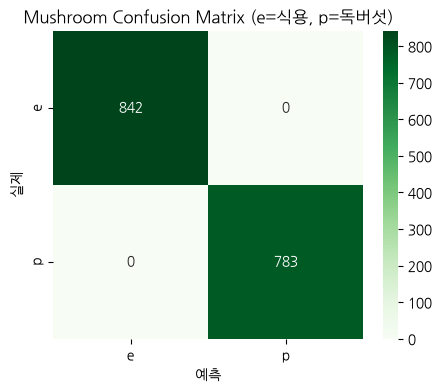

In [5]:
# 성능 평가

y_pred = best_model.predict(x_test)

print(f'Train Score : {best_model.score(x_train, y_train):.4f}')
print(f'Test  Score : {best_model.score(x_test,  y_test):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
cmDF = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cmDF, annot=True, fmt='d', cmap='Greens')
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Mushroom Confusion Matrix (e=식용, p=독버섯)')
plt.show()

In [7]:
# 모델 저장

os.makedirs('../Data/Models', exist_ok=True)
joblib.dump(best_model, '../Data/Models/mushroom_model.pkl')
print(f'모델 저장')

new_mushroom = x_test.iloc[[0]]
pred = best_model.predict(new_mushroom)
actual = le.inverse_transform([y_test[0]])[0]

print(f'\n예측 결과 : {le.inverse_transform(pred)[0]}  (e=식용, p=독버섯)')
print(f'실제 정답 : {actual}')

모델 저장 완료 : ../Models/mushroom_model.pkl

예측 결과 : p  (e=식용, p=독버섯)
실제 정답 : p
